In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [2]:
df = pd.read_csv(r'C:\Users\e.i.chapaev\Desktop\serious_udgu_pr\clearing_df.csv')

In [4]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
model = KNeighborsClassifier(n_neighbors=10, weights="distance")
model.fit(X_train, y_train)

# 4. Предсказание
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 76.92%


In [16]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba[:, 1]):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.769
Precision:0.727
Recall:  1.000
F1-score: 0.842
ROC-AUC:0.950

Confusion Matrix:
 [[2 3]
 [0 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.40      0.57         5
         1.0       0.73      1.00      0.84         8

    accuracy                           0.77        13
   macro avg       0.86      0.70      0.71        13
weighted avg       0.83      0.77      0.74        13



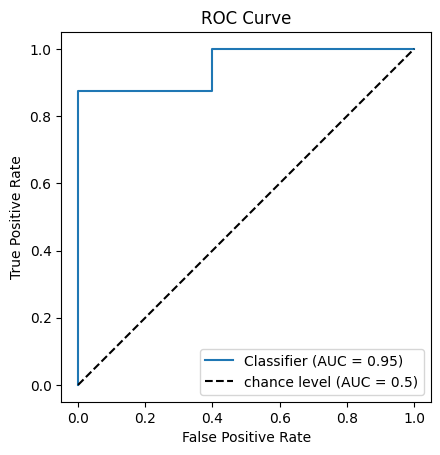

In [18]:
RocCurveDisplay.from_predictions(y_test, y_proba[:, 1])

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

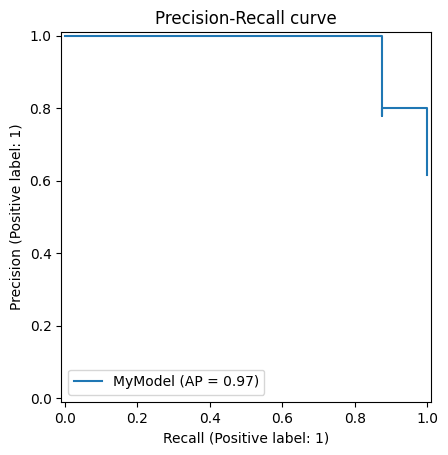

In [19]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba[:, 1], name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()